In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nvitk.core as core
core.setup(globals())

In [ ]:
from nilearn.datasets import load_fsaverage
from nilearn.surface import SurfaceImage
from nilearn import datasets

from nvitk import io

# Load surface mesh 
fsaverage = load_fsaverage("fsaverage5")

# Load your custom 3D atlas (NIfTI file)
# custom_atlas_img = datasets.load_sample_motor_activation_image() 
custom_atlas_img = io.imread("/home/imarcoss/NetVolumes/LAB_MCC/LabVF/PESA-Brain/DB/raw/ATLAS/ctx_arterial_atlas_watershed_filled.nii.gz")
custom_atlas_img

Image(shape=(79, 95, 79), dtype=float32, backend=cupy, axes='XYZ', orientation='LAS', name='ctx_arterial_atlas_watershed.nii', modality=None, submodality=None, rescale_type='DV')

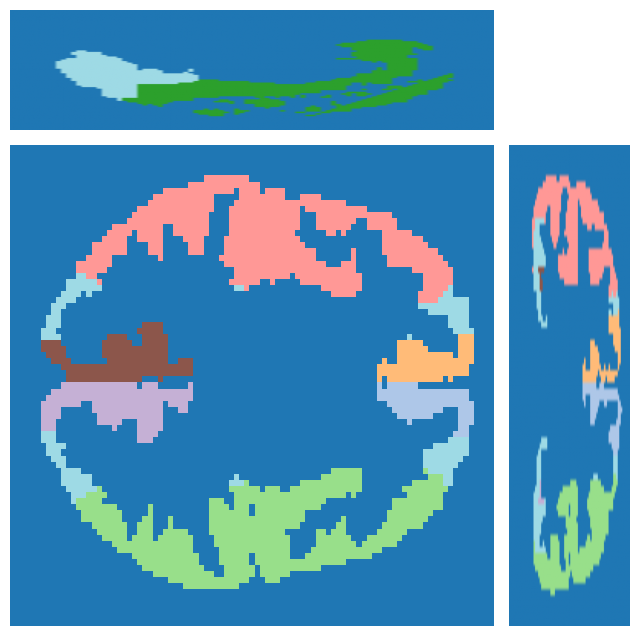

In [21]:
io.imshow(custom_atlas_img, cmap="tab20")

In [ ]:
import nibabel as nib
custom_atlas_img = nib.load("/home/imarcoss/NetVolumes/LAB_MCC/LabVF/PESA-Brain/DB/raw/ATLAS/ctx_arterial_atlas_watershed_filled.nii.gz")
custom_atlas_img.dataobj
custom_atlas_img.affine
custom_atlas_img.header
custom_atlas_img.header.get_zooms()

_sulcal = load_fsaverage_data(data_type="sulcal")

custom_atlas_img

In [48]:
fsaverage

{'description': ".. _fs_average_5_template:\n\nfsaverage5 template\n===================\n\nAccess\n------\nSee :func:`nilearn.datasets.fetch_surf_fsaverage`.\n\nNotes\n-----\nFsaverage5 standard surface as distributed with Freesurfer (:footcite:t:`Fischl1999`).\n\nContent\n-------\n    :'area_left': Gifti file, left hemisphere area data\n    :'area_right': Gifti file, right hemisphere area data\n    :'curv_left': Gifti file, left hemisphere curvature data\n    :'curv_right': Gifti file, right hemisphere curvature data\n    :'flat_left': Gifti file, left hemisphere flat surface mesh\n    :'flat_right': Gifti file, right hemisphere flat surface mesh\n    :'pial_left': Gifti file, left hemisphere pial surface mesh\n    :'pial_right': Gifti file, right hemisphere pial surface mesh\n    :'infl_left': Gifti file, left hemisphere inflated pial surface mesh\n    :'infl_right': Gifti file, right hemisphere inflated pial\n                   surface mesh\n    :'sphere_left': Gifti file, left hemi

In [69]:
surface_atlas = SurfaceImage.from_volume(
    mesh=fsaverage["pial"],
    volume_img=custom_atlas_img,
    interpolation="nearest",
    radius=1,
    # kind="ball",
)   

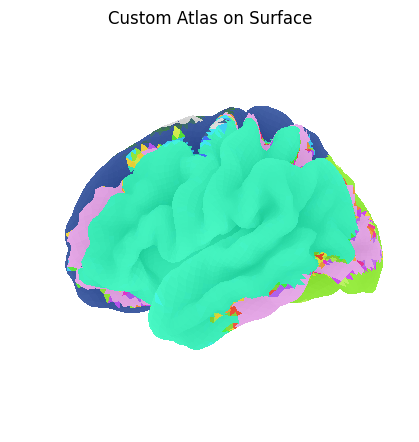

In [74]:
from nilearn.plotting import plot_surf_roi, plot_surf_stat_map
from nilearn.datasets import load_fsaverage_data

# Plot the projected atlas on the inflated surface
plot_surf_roi(
    roi_map=surface_atlas,
    surf_mesh=fsaverage["pial"],
    hemi="left",
    bg_map=_sulcal, 
    bg_on_data=True,
    title="Custom Atlas on Surface"
);   

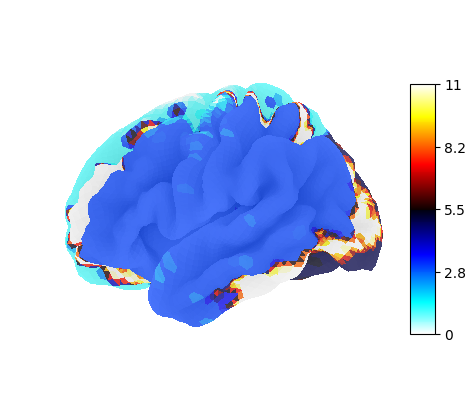

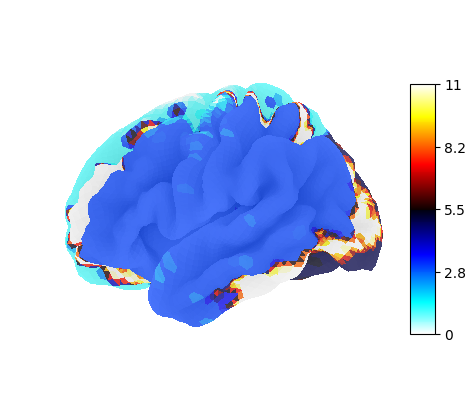

In [76]:
plot_surf_stat_map(
    surf_mesh=fsaverage["pial"],
    stat_map=surface_atlas,
    hemi="left",
    bg_map=_sulcal,
    bg_on_data=True,
)

(<Figure size 426.667x480 with 5 Axes>,
 [<Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes: >])

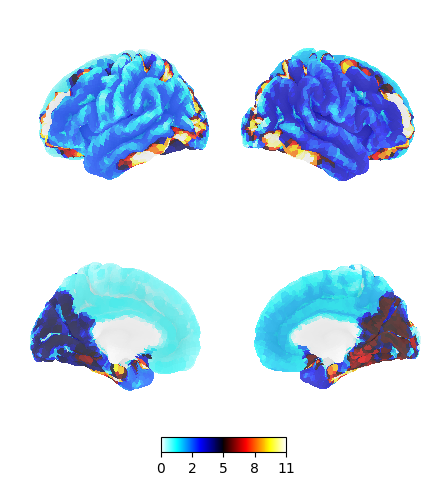

In [73]:
from nilearn.plotting import plot_img_on_surf

plot_img_on_surf(
    stat_map=custom_atlas_img,
    # mask_img=custom_atlas_img,
    surf_mesh='fsaverage5',
    hemispheres=["left", "right"],
    views=["lateral", "medial"],
    # bg_map=_sulcal,
    bg_on_data=True,
    avg_method="max",
)